In [1]:
import numpy as np
import pandas as pd
import os
import joblib
import pickle
import math
import ast

from scipy.stats import median_abs_deviation, hypergeom, mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

%matplotlib inline

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

In [2]:
import sys
# Ensure this analysis directory is importable regardless of kernel CWD
_here = '/projects/bhdw/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/analysis'
if _here not in sys.path:
    sys.path.insert(0, _here)

import dictys
from utils_custom import *
from pseudotime_curves import *
from episodic_dynamics import *
from config import *

In [3]:
import importlib
import firefate.utils.plots, firefate.utils.custom
import state_dynamics
# re-bind
importlib.reload(firefate.utils.plots)
importlib.reload(firefate.utils.custom)
importlib.reload(state_dynamics)

<module 'state_dynamics' from '/projects/bhdw/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/analysis/state_dynamics.py'>

In [4]:
config = Config()

In [5]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file('/work/nvme/bhdw/asachan/data_files/firefate/bcell/outs/dynamic.h5')

In [6]:
PB_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2]
GC_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3]
PB_post_bifurcation_window_indices = [0] + list(range(98, 147, 1)) + [2]
GC_post_bifurcation_window_indices = [0] + list(range(147, 193, 1)) + [3]

In [7]:
# Define distinct colors for better visibility
colors_cell_count = {
    'ActB-1': '#87CEFA',     # lightskyblue
    'ActB-2': '#1E90FF',     # dodgerblue
    'ActB-3': '#00008B',     # darkblue
    'ActB-4': '#9370DB',     # mediumorchid
    'GC-1': '#7BDE7B',       # custom light green
    'GC-2': '#008000',       # green
    'PB-2': '#BB3636',       # custom red
    'earlyActB': '#008080',   # teal
    'earlyPB': '#F08080'   # lightcoral
}

## Episodic links clustered by regulatory phases present in PB and GC lineages

In [8]:
# load the episodically enriched links from file
episodic_links_file = '/projects/bhdw/asachan/papers/firefate/figures/enriched_tf_lf_targets_per_episode.csv'
episodic_links = pd.read_csv(episodic_links_file)

In [9]:
#create tuples from the TF and genes_in_lf list of comma separated targets and take union of all links across all rows to make a unique set of links
episodic_links_tuples = set()
for _, row in episodic_links.iterrows():
    tf = row['TF']
    targets = row['genes_in_lf'].split(',')
    for target in targets:
        episodic_links_tuples.add((tf, target.strip()))

display(len(episodic_links_tuples))

55

## PB links

In [10]:
import state_dynamics as sd

In [11]:
# TF forces over pseudotime (expression / regulation curves cached internally)
waves_pb = sd.TFForceWaves(
    dictys_dynamic_object,
    trajectory_range=(0, 2),
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)

In [12]:
# episodic links as (TF, target) tuples (already built in the cell above)
links = sorted(episodic_links_tuples)

# 1) compute & cache force curves for these links on the PB branch (0->2)
waves_pb.compute_forces(links)

time_0    time_1    time_2    time_3    time_4    time_5  \
TF    Target                                                                
MEF2A PAX5     0.237337  0.266643  0.292164  0.314832  0.335196  0.353610   
      FNDC3A  -0.322953 -0.327366 -0.331355 -0.334924 -0.338077 -0.340818   
      ARNTL2  -0.213650 -0.203788 -0.193582 -0.183012 -0.172043 -0.160619   
      UBAC2    0.419271  0.421486  0.423281  0.424702  0.425799  0.426623   
      CD74     0.120064  0.114459  0.107306  0.097969  0.085306  0.066602   
...                 ...       ...       ...       ...       ...       ...   
IRF8  GLCCI1   0.259717  0.271253  0.282122  0.292343  0.301928  0.310884   
      B2M     -0.319980 -0.317743 -0.315761 -0.314131 -0.312939 -0.312260   
      HSP90B1  0.117514  0.106588  0.091744  0.070025  0.019796 -0.068827   
      SUB1     0.103271  0.108953  0.113922  0.118323  0.122263  0.125829   
      TXNDC5   0.170909  0.173225  0.174869  0.175886  0.176322  0.176220   

                 time_6    time_7    time_8    time_9  ...   time_90  \
TF    Target                                           ...             
MEF2A PAX5     0.370316  0.385490  0.399266  0.411751  ...  0.268532   
      FNDC3A  -0.343152 -0.345081 -0.346608 -0.347735  ...  0.393043   
      ARNTL2  -0.148650 -0.135993 -0.122413 -0.107504  ...  0.417916   
      UBAC2    0.427226  0.427659  0.427971  0.428209  ...  0.303089   
      CD74     0.026704 -0.062662 -0.089463 -0.110173  ... -0.488241   
...                 ...       ...       ...       ...  ...       ...   
IRF8  GLCCI1   0.319215  0.326924  0.334015  0.340489  ... -0.162168   
      B2M     -0.312156 -0.312674 -0.313843 -0.315679  ... -0.244312   
      HSP90B1 -0.095307 -0.115247 -0.131871 -0.146322  ...  0.152139   
      SUB1     0.129090  0.132107  0.134933  0.137618  ... -0.384675   
      TXNDC5   0.175627  0.174589  0.173154  0.171373  ... -0.162842   

                time_91   time_92   time_93   time_94   time_95   time_96  \
TF    Target                                                                
MEF2A PAX5     0.275771  0.283088  0.290453  0.297837  0.305217  0.312572   
      FNDC3A   0.389628  0.385767  0.381502  0.376877  0.371937  0.366727   
      ARNTL2   0.411946  0.405617  0.398958  0.392001  0.384775  0.377309   
      UBAC2    0.299438  0.295432  0.291082  0.286402  0.281407  0.276111   
      CD74    -0.474377 -0.460203 -0.445758 -0.431081 -0.416206 -0.401167   
...                 ...       ...       ...       ...       ...       ...   
IRF8  GLCCI1  -0.134546 -0.094501  0.055823  0.116978  0.152461  0.180118   
      B2M     -0.253028 -0.259681 -0.264488 -0.267608 -0.269157 -0.269218   
      HSP90B1  0.172734  0.191759  0.209657  0.226688  0.243019  0.258763   
      SUB1    -0.400298 -0.416221 -0.432365 -0.448660 -0.465044 -0.481466   
      TXNDC5  -0.152918 -0.141166 -0.126988 -0.109232 -0.085099 -0.040940   

                time_97   time_98   time_99  
TF    Target                                 
MEF2A PAX5     0.319882  0.327131  0.334304  
      FNDC3A   0.361295  0.355686  0.349949  
      ARNTL2   0.369633  0.361773  0.353758  
      UBAC2    0.270530  0.264678  0.258573  
      CD74    -0.385991 -0.370704 -0.355326  
...                 ...       ...       ...  
IRF8  GLCCI1   0.203588  0.224347  0.243162  
      B2M     -0.267851 -0.265089 -0.260946  
      HSP90B1  0.273997  0.288778  0.303145  
      SUB1    -0.497877 -0.514239 -0.530514  
      TXNDC5   0.071232  0.102809  0.125725  

[434 rows x 100 columns]

In [13]:
# 2) PB phase boundaries = cell-state termination pseudotimes (3 phases)
sf = sd.StateFrequency(
    dictys_dynamic_object,
    cell_labels=config.CELL_LABELS,
    colors=colors_cell_count,
    trajectory_range=(0, 2),
)
switch_pseudotimes = [
    sf.termination_pseudotime(state, PB_post_bifurcation_window_indices)
    for state in ['ActB-4', 'earlyPB']
]

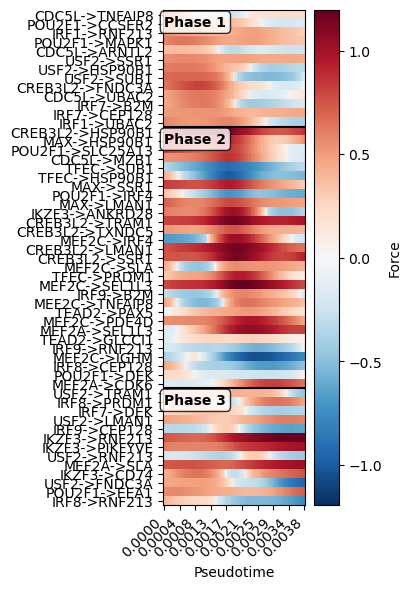

In [14]:
ordered_df, phases, fig = sd.plot_force_heatmap_by_phase(
    force_curves=waves_pb.force_curves,
    dtime=waves_pb.dtime,
    links=links,
    switch_pseudotimes=switch_pseudotimes,
)
plt.show()

In [14]:
# selected links for plotting
pb_episodic_links = [('IRF1', 'UBAC2'),('CDC5L', 'UBAC2'),('USF2', 'SUB1'),('POU2F1', 'MAPK1'), 
                     ('CREB3L2', 'HSP90B1'), ('MAX', 'HSP90B1'), ('TFEC', 'HSP90B1'), ('MEF2A', 'CDK6'), ('MEF2A', 'SEL1L3'), ('MEF2C', 'SEL1L3'), ('MEF2C', 'IGHM'), ('MEF2C', 'PDE4D'),
                     ('IKZF3', 'RNF213'), ('IRF8', 'RNF213'), ('IRF8', 'PRDM1'), ('MEF2A', 'SLA')]

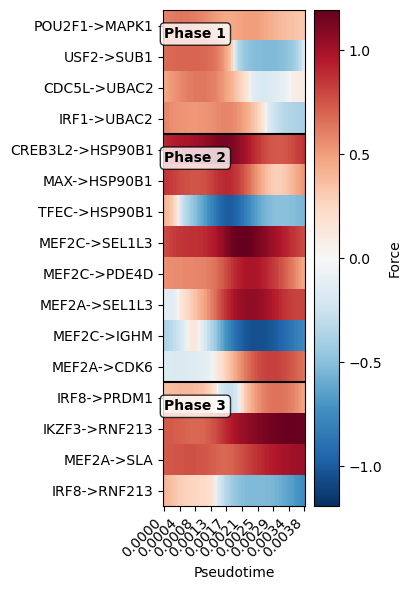

In [15]:
ordered_df_subset, phases, fig = sd.plot_force_heatmap_by_phase(
    force_curves=waves_pb.force_curves,
    dtime=waves_pb.dtime,
    links=pb_episodic_links,
    switch_pseudotimes=switch_pseudotimes,
)
fig.savefig('/projects/bhdw/asachan/papers/firefate/figures/pb_episodic_links_phase.svg',
            format='svg', bbox_inches='tight')
plt.show()

## GC links

In [16]:
# TF forces over pseudotime (expression / regulation curves cached internally)
waves_gc = sd.TFForceWaves(
    dictys_dynamic_object,
    trajectory_range=(0, 3),
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)

In [17]:
# episodic links as (TF, target) tuples (already built in the cell above)
links = sorted(episodic_links_tuples)

# 1) compute & cache force curves for these links on the PB branch (0->2)
waves_gc.compute_forces(links)

time_0    time_1    time_2    time_3    time_4    time_5  \
TF    Target                                                                
MEF2A PAX5     0.237337  0.240186  0.242678  0.244792  0.246504  0.247783   
      FNDC3A  -0.322953 -0.325733 -0.328469 -0.331174 -0.333863 -0.336552   
      ARNTL2  -0.213650 -0.211688 -0.209868 -0.208221 -0.206782 -0.205589   
      UBAC2    0.419271  0.419792  0.420079  0.420121  0.419906  0.419422   
      CD74     0.120064  0.121579  0.122794  0.123639  0.124037  0.123893   
...                 ...       ...       ...       ...       ...       ...   
IRF8  GLCCI1   0.259717  0.261932  0.264141  0.266358  0.268601  0.270886   
      B2M     -0.319980 -0.314550 -0.308678 -0.302328 -0.295455 -0.288003   
      HSP90B1  0.117514  0.123583  0.129055  0.134024  0.138560  0.142720   
      SUB1     0.103271  0.103690  0.103835  0.103714  0.103329  0.102681   
      TXNDC5   0.170909  0.175431  0.179800  0.184037  0.188162  0.192194   

                 time_6    time_7    time_8    time_9  ...   time_90  \
TF    Target                                           ...             
MEF2A PAX5     0.248590  0.248881  0.248601  0.247682  ...  0.325136   
      FNDC3A  -0.339261 -0.342005 -0.344807 -0.347687  ...  0.333575   
      ARNTL2  -0.204684 -0.204112 -0.203920 -0.204155  ...  0.307964   
      UBAC2    0.418655  0.417587  0.416201  0.414476  ...  0.415219   
      CD74     0.123093  0.121493  0.118905  0.115074  ...  0.128398   
...                 ...       ...       ...       ...  ...       ...   
IRF8  GLCCI1   0.273231  0.275652  0.278170  0.280802  ...  0.214951   
      B2M     -0.279903 -0.271070 -0.261395 -0.250740  ...  0.387804   
      HSP90B1  0.146548  0.150080  0.153347  0.156376  ... -0.200218   
      SUB1     0.101768  0.100585  0.099121  0.097363  ... -0.169783   
      TXNDC5   0.196151  0.200052  0.203915  0.207756  ...  0.133726   

                time_91   time_92   time_93   time_94   time_95   time_96  \
TF    Target                                                                
MEF2A PAX5     0.329308  0.333353  0.337282  0.341102  0.344821  0.348445   
      FNDC3A   0.333288  0.332913  0.332456  0.331921  0.331316  0.330644   
      ARNTL2   0.306799  0.305651  0.304519  0.303403  0.302304  0.301221   
      UBAC2    0.414131  0.413062  0.412013  0.410983  0.409974  0.408986   
      CD74     0.138927  0.148526  0.157400  0.165690  0.173495  0.180890   
...                 ...       ...       ...       ...       ...       ...   
IRF8  GLCCI1   0.213977  0.212995  0.212005  0.211007  0.210000  0.208986   
      B2M      0.391159  0.394359  0.397411  0.400324  0.403105  0.405761   
      HSP90B1 -0.201364 -0.202479 -0.203565 -0.204621 -0.205648 -0.206647   
      SUB1    -0.168215 -0.166600 -0.164937 -0.163224 -0.161459 -0.159643   
      TXNDC5   0.132071  0.130336  0.128520  0.126623  0.124642  0.122575   

                time_97   time_98   time_99  
TF    Target                                 
MEF2A PAX5     0.351980  0.355433  0.358807  
      FNDC3A   0.329909  0.329116  0.328269  
      ARNTL2   0.300155  0.299105  0.298072  
      UBAC2    0.408017  0.407070  0.406142  
      CD74     0.187935  0.194673  0.201140  
...                 ...       ...       ...  
IRF8  GLCCI1   0.207963  0.206932  0.205892  
      B2M      0.408298  0.410723  0.413041  
      HSP90B1 -0.207618 -0.208561 -0.209478  
      SUB1    -0.157772 -0.155845 -0.153861  
      TXNDC5   0.120420  0.118173  0.115832  

[434 rows x 100 columns]

In [18]:
# 2) GC phase boundaries = cell-state termination pseudotimes (2 phases)
sf = sd.StateFrequency(
    dictys_dynamic_object,
    cell_labels=config.CELL_LABELS,
    colors=colors_cell_count,
    trajectory_range=(0, 3),
)
switch_pseudotimes = [
    sf.termination_pseudotime(state, GC_post_bifurcation_window_indices)
    for state in ['ActB-3']
]

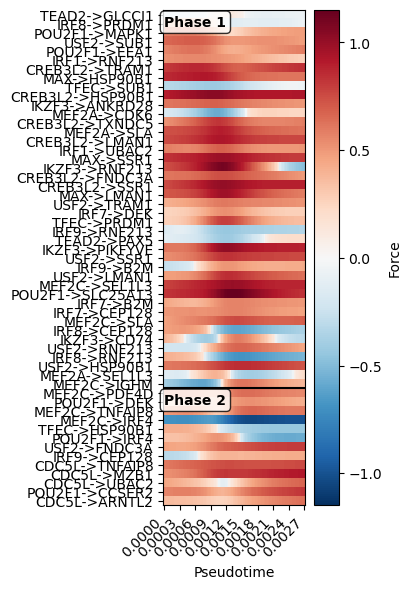

In [21]:
ordered_df, phases, fig = sd.plot_force_heatmap_by_phase(
    force_curves=waves_gc.force_curves,
    dtime=waves_gc.dtime,
    links=links,
    switch_pseudotimes=switch_pseudotimes,
)
plt.show()

In [19]:
# selected links for plotting
gc_episodic_links = [('TEAD2', 'GLCC1'), ('TEAD2', 'PAX5'), ('IKZF3', 'RNF213'), ('IKFZF3', 'PIKFYVE'), ('POU2F1', 'SLC25A13'), ('IRF8', 'CEP128'), ('IRF8', 'RNF213'), ('USF2', 'RNF213'), ('MEF2A', 'SEL1L3'), ('MEF2C', 'IGHM'), ('MAX', 'LMAN1'), ('USF2', 'LMAN1'),
                     ('MEF2C', 'IRF4'), ('POU2F1', 'IRF4'), ('POU2F1', 'CCSER2'), ('CDC5L','MZB1')]

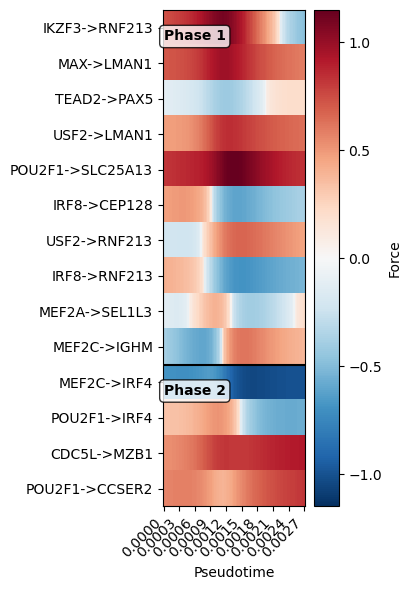

In [20]:
ordered_df_subset, phases, fig = sd.plot_force_heatmap_by_phase(
    force_curves=waves_gc.force_curves,
    dtime=waves_gc.dtime,
    links=gc_episodic_links,
    switch_pseudotimes=switch_pseudotimes,
)
fig.savefig('/projects/bhdw/asachan/papers/firefate/figures/gc_episodic_links_phase.svg',
            format='svg', bbox_inches='tight')
plt.show()